# Gachibowli Diurnal Population Simulation
## Refined Version with Animated Visualization

This notebook simulates population movement patterns in Gachibowli throughout a typical day,
based on building types, employment patterns, and work schedules.

**Key Features:**
- Building-based population classification
- Gaussian-distributed work timing
- Realistic movement patterns
- Animated MP4 visualization
- Comprehensive data export

---
## 1. Setup and Configuration

### 1.1 Import Required Libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
import seaborn as sns

# Spatial analysis
from scipy.spatial.distance import cdist
from scipy.stats import norm
import osmnx as ox

# Utilities
import os
import json
import warnings
from datetime import datetime
from tqdm.notebook import tqdm

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
ox.settings.log_console = False
ox.settings.use_cache = True

print("✓ All libraries imported successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | GeoPandas: {gpd.__version__}")

✓ All libraries imported successfully!
NumPy: 1.26.4 | Pandas: 2.1.4 | GeoPandas: 1.1.1


In [ ]:
# Install optional dependencies if needed
%pip install matplotlib-scalebar -q

# Install contextily for satellite basemap (optional but recommended)
# Uncomment the line below to install:
# %pip install contextily -q

Note: you may need to restart the kernel to use updated packages.


### 1.2 Define Simulation Parameters

In [ ]:
# ============================================================================
# FILE PATHS - Update these to match your local file locations
# ============================================================================
BUILDINGS_PATH = '/Users/va/Geospatial/Buildings/WEST_ZONE_BLDG_HGT_POP_MEAN.shp'
BOUNDARY_PATH = '/Users/va/Geospatial/Boundary/UTM44N_GCKMMHS_ZONE_POLY_DSLV_EXTN.shp'
OUTPUT_DIR = '/Users/va/Geospatial/outputs'

# ============================================================================
# EMPLOYMENT DISTRIBUTION (PLFS 2024 Survey Data)
# ============================================================================
EMPLOYMENT_DISTRIBUTION = {
    'self_employed_own': 0.1313,      # 13.13% - Own account workers
    'self_employed_helper': 0.0264,   # 2.64% - Helpers in household enterprises
    'regular_salaried': 0.1933,       # 19.33% - Regular salaried employees
    'casual_labour': 0.0425,          # 4.25% - Casual labour
    'unemployed': 0.0206,             # 2.06% - Unemployed
    'homemakers_elderly': 0.3792,     # 37.92% - Homemakers and elderly
    'students_children': 0.2067       # 20.67% - Students and children (adjusted to sum to 1.0)
}

# Verify probabilities sum to 1.0
assert abs(sum(EMPLOYMENT_DISTRIBUTION.values()) - 1.0) < 1e-10, "Employment probabilities must sum to 1.0"

# ============================================================================
# LAND USE CLASSIFICATION
# ============================================================================
LULC_CODES = {
    'RESI': 'Residential',
    'COMB': 'Commercial-NonIT',
    'COMI': 'Commercial-IT',
    'INDU': 'Industrial',
    'INST': 'Institutional',
    'RECR': 'Recreation',
    'NCNU': 'NotClassified'
}

# ============================================================================
# WORK SCHEDULES WITH GAUSSIAN DISTRIBUTIONS
# ============================================================================
WORK_SCHEDULES = {
    'COMI': {  # IT/Tech Companies
        'days': 'MON-FRI',
        'pattern': 'H->W->H',
        'start_mean': 8.0,    # 8:00 AM
        'start_std': 0.67,    # ~2 hour spread (6-10 AM)
        'start_min': 6.0,
        'start_max': 10.0,
        'end_mean': 18.0,     # 6:00 PM
        'end_std': 1.0,       # ~3 hour spread (4-10 PM)
        'end_min': 16.0,
        'end_max': 22.0
    },
    'COMB': {  # Retail/Services
        'days': 'ALL',
        'pattern': 'ALL_DAY',
        'start_mean': 9.5,    # 9:30 AM
        'start_std': 0.5,
        'start_min': 8.0,
        'start_max': 11.0,
        'end_mean': 22.0,     # 10:00 PM
        'end_std': 0.67,
        'end_min': 21.0,
        'end_max': 23.0
    },
    'INDU': {  # Industrial
        'days': 'MON-SAT',
        'pattern': 'H->W->H',
        'start_mean': 8.0,
        'start_std': 0.67,
        'start_min': 6.0,
        'start_max': 10.0,
        'end_mean': 17.0,
        'end_std': 1.0,
        'end_min': 15.0,
        'end_max': 19.0
    },
    'INST': {  # Schools/Institutions
        'days': 'MON-FRI',
        'pattern': 'H->W->H',
        'start_mean': 8.5,
        'start_std': 0.5,
        'start_min': 7.0,
        'start_max': 9.5,
        'end_mean': 16.0,
        'end_std': 0.67,
        'end_min': 14.0,
        'end_max': 18.0
    },
    'RECR': {  # Recreation
        'days': 'ALL',
        'pattern': 'ALL_DAY',
        'start_mean': 10.0,
        'start_std': 1.0,
        'start_min': 8.0,
        'start_max': 12.0,
        'end_mean': 21.0,
        'end_std': 1.0,
        'end_min': 18.0,
        'end_max': 23.0
    }
}

print("✓ Configuration parameters defined")
print(f"\nEmployment categories: {len(EMPLOYMENT_DISTRIBUTION)}")
print(f"Building types: {len(LULC_CODES)}")
print(f"Work schedule types: {len(WORK_SCHEDULES)}")
print(f"\nEmployment distribution sum: {sum(EMPLOYMENT_DISTRIBUTION.values()):.10f}")

✓ Configuration parameters defined

Employment categories: 7
Building types: 7
Work schedule types: 5

Employment distribution sum: 1.0000000000


---
## 2. Data Loading and Preparation



```
# This is formatted as code
```

### 2.1 Load Building and Boundary Data

In [ ]:
print("="*80)
print("LOADING GEOSPATIAL DATA")
print("="*80)

try:
    # Load buildings shapefile
    buildings_gdf = gpd.read_file(BUILDINGS_PATH)
    print(f"\n✓ Buildings loaded: {len(buildings_gdf):,} features")
    print(f"  Columns: {list(buildings_gdf.columns)}")
    print(f"  CRS: {buildings_gdf.crs}")

    # Load boundary (optional)
    try:
        boundary_gdf = gpd.read_file(BOUNDARY_PATH)
        print(f"\n✓ Boundary loaded: {len(boundary_gdf)} feature(s)")
    except:
        boundary_gdf = None
        print("\n⚠ Boundary file not found (optional)")

    # Display basic statistics
    print("\n" + "="*80)
    print("DATA OVERVIEW")
    print("="*80)
    display(buildings_gdf.head(3))

except FileNotFoundError as e:
    print(f"\n❌ ERROR: {e}")
    print("\nPlease update the file paths in Section 1.2")
    buildings_gdf = None
    boundary_gdf = None

LOADING GEOSPATIAL DATA

✓ Buildings loaded: 53,797 features
  Columns: ['full_id', 'osm_id', 'osm_type', 'building', 'addr_postc', 'type', 'name', 'HGT_count', 'HGT_mean', 'HGT_median', 'HGT_stdev', 'HGT_min', 'HGT_max', 'HGT_varian', 'Level_lV', 'Level_PRJ', 'LU_PRJ', 'LU_B_PRJ', 'B_FLOOR', 'B_FLOOR_AR', 'B_POP_SHAR', 'geometry']
  CRS: EPSG:32644

✓ Boundary loaded: 1 feature(s)

DATA OVERVIEW


,full_id,osm_id,osm_type,building,addr_postc,type,name,HGT_count,HGT_mean,HGT_median,...,HGT_max,HGT_varian,Level_lV,Level_PRJ,LU_PRJ,LU_B_PRJ,B_FLOOR,B_FLOOR_AR,B_POP_SHAR,geometry
0,r2829427,2829427,relation,university,None,multipolygon,Vindhya,606.0,6.845052,7.046875,...,13.312500,7.757468,Built Up - Peri Urban,INST_PU,INST,INST,4,38245.052010,97,"POLYGON ((218464.733 1930909.059, 218483.602 1..."
1,r4853123,4853123,relation,yes,None,multipolygon,Indian School of Business,526.0,11.724409,12.957031,...,22.914062,35.174348,Built Up - Peri Urban,INST_PU,INST,INST,7,57267.812011,74,"POLYGON ((217358.158 1929663.128, 217362.848 1..."
2,r5167100,5167100,relation,commercial,None,multipolygon,None,764.0,23.434780,24.085938,...,37.164062,49.078942,Built Up - Core Urban,RESI,RESI,RESI,12,134654.929385,82,"POLYGON ((220923.318 1931136.768, 220954.524 1..."


### 2.2 Examine and Validate Data Structure

In [ ]:
if buildings_gdf is not None:
    print("\n" + "="*80)
    print("DATA VALIDATION")
    print("="*80)

    # Check required columns
    required_cols = ['LU_B_PRJ', 'B_FLOOR_AR', 'B_POP_SHAR', 'HGT_max', 'B_FLOOR']
    print("\nRequired columns:")
    for col in required_cols:
        status = "✓" if col in buildings_gdf.columns else "✗"
        print(f"  {status} {col}")

    # LULC distribution
    if 'LU_B_PRJ' in buildings_gdf.columns:
        print("\nLand Use Distribution:")
        lulc_dist = buildings_gdf['LU_B_PRJ'].value_counts()
        for code, count in lulc_dist.items():
            name = LULC_CODES.get(code, 'Unknown')
            pct = (count / len(buildings_gdf)) * 100
            print(f"  {code} ({name}): {count:,} ({pct:.1f}%)")

    # Numeric statistics
    print("\nNumeric Column Statistics:")
    display(buildings_gdf.describe())
else:
    print("⚠ Skipping validation - no data loaded")


DATA VALIDATION

Required columns:
  ✓ LU_B_PRJ
  ✓ B_FLOOR_AR
  ✓ B_POP_SHAR
  ✓ HGT_max
  ✓ B_FLOOR

Land Use Distribution:
  RESI (Residential): 50,108 (93.1%)
  COMB (Commercial-NonIT): 1,340 (2.5%)
  NCNU (NotClassified): 892 (1.7%)
  COMI (Commercial-IT): 675 (1.3%)
  INST (Institutional): 586 (1.1%)
  INDU (Industrial): 165 (0.3%)
  RECR (Recreation): 31 (0.1%)

Numeric Column Statistics:


,HGT_count,HGT_mean,HGT_median,HGT_stdev,HGT_min,HGT_max,HGT_varian,B_FLOOR,B_FLOOR_AR,B_POP_SHAR
count,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000,53797.000000
mean,14.534305,7.501285,7.889368,2.164379,3.630170,10.198605,9.794927,3.184025,1400.588177,7.506422
std,51.876402,5.740402,6.436432,2.260638,3.504851,7.754233,41.162986,2.441425,11021.353764,13.075715
min,0.134969,0.013416,0.000000,0.000000,0.000000,2.507812,0.000000,1.000000,1.867365,0.000000
25%,5.000000,4.112723,4.171875,0.878906,1.054688,5.695312,0.772476,2.000000,158.642670,1.000000
50%,8.000000,6.024740,6.230469,1.586251,2.992188,8.289062,2.516192,3.000000,306.959487,3.000000
75%,12.000000,9.248047,9.757812,2.697591,5.046875,12.351562,7.276999,4.000000,578.371365,7.000000
max,5914.000000,89.043870,94.703125,38.948342,86.976562,98.609375,1516.973348,31.000000,847690.794661,156.000000


### 2.3 Download Road Network from OpenStreetMap

In [ ]:
def download_osm_roads(boundary_gdf=None, place_name="Gachibowli, Hyderabad, India",
                       network_type='drive', buffer_dist=500):
    """
    Download road network from OpenStreetMap

    Parameters:
    -----------
    boundary_gdf : GeoDataFrame
        Boundary polygon to download roads within (should be in WGS84)
    place_name : str
        Name of the place if boundary_gdf is None
    network_type : str
        Type of road network ('drive', 'walk', 'bike', 'all')
    buffer_dist : int
        Buffer distance in meters around boundary

    Returns:
    --------
    GeoDataFrame with road network
    """
    print("\n" + "="*80)
    print("DOWNLOADING ROAD NETWORK FROM OPENSTREETMAP")
    print("="*80)


    if boundary_gdf is not None and len(boundary_gdf) > 0:
        # Use boundary polygon
        print(f"\nUsing provided boundary polygon...")

        # Ensure boundary is in WGS84 (required for OSM)
        if boundary_gdf.crs != 'EPSG:4326':
            print(f"Reprojecting boundary from {boundary_gdf.crs} to WGS84...")
            boundary_gdf = boundary_gdf.to_crs('EPSG:4326')

        # Get the boundary geometry
        boundary_polygon = boundary_gdf.unary_union

        # Add buffer to ensure we get roads at the edges
        if buffer_dist > 0:
            print(f"Applying {buffer_dist}m buffer to boundary...")
            # Reproject to metric CRS for buffering (UTM Zone 44N for Hyderabad)
            gdf_metric = boundary_gdf.to_crs('EPSG:32644')
            buffered = gdf_metric.buffer(buffer_dist)
            boundary_polygon = buffered.to_crs('EPSG:4326').unary_union

        # Download road network using polygon
        print(f"Downloading '{network_type}' network from OSM...")
        print("This may take 1-2 minutes depending on area size...")
        G = ox.graph_from_polygon(boundary_polygon, network_type=network_type)


        # Convert to GeoDataFrame (edges only)
        print("\nConverting graph to GeoDataFrame...")
        edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

        print(f"\n✓ Downloaded {len(edges):,} road segments")
        print(f"✓ CRS: {edges.crs}")

        # Display road types
        if 'highway' in edges.columns:
            print("\nRoad Types Distribution:")
            road_types = edges['highway'].value_counts()
            for road_type, count in road_types.head(10).items():
                print(f"  {road_type:<20}: {count:>6,}")

        return edges

    except Exception as e:
        print(f"\n⚠️ Error downloading road network: {e}")
        print("\nPossible solutions:")
        print("  1. Check internet connection")
        print("  2. Try a different place_name")
        print("  3. Ensure boundary is in correct projection")
        print("  4. Reduce buffer_dist if area is too large")
        return None


# Download road network
road_network_gdf = None

if buildings_gdf is not None:
    if boundary_gdf is not None:
        # Use boundary polygon with buffer
        print("Using boundary polygon for road network download...")
        boundary_wgs84 = boundary_gdf.to_crs('EPSG:4326')
        road_network_gdf = download_osm_roads(
            boundary_gdf=boundary_wgs84,
            buffer_dist=1000,  # 1km buffer
            network_type='drive'
        )
    else:
        # Use place name as fallback
        print("No boundary provided, using place name...")
        road_network_gdf = download_osm_roads(
            place_name="Gachibowli, Hyderabad, India",
            network_type='drive'
        )

    # Reproject to match buildings CRS if successful
    if road_network_gdf is not None:
        print(f"\nReprojecting road network to match buildings CRS...")
        road_network_gdf = road_network_gdf.to_crs(buildings_gdf.crs)
        print(f"✓ Road network CRS: {road_network_gdf.crs}")

        # Save road network to shapefile
        try:
            os.makedirs(OUTPUT_DIR, exist_ok=True)
            roads_output_path = os.path.join(OUTPUT_DIR, 'road_network.shp')

            # Select important columns for shapefile (avoid column name length issues)
            export_columns = ['geometry', 'highway', 'name', 'length']
            available_columns = [col for col in export_columns if col in road_network_gdf.columns]

            road_network_export = road_network_gdf[available_columns].copy()

            # Shorten column names for shapefile (10-char limit)
            column_mapping = {
                'highway': 'road_type',
                'name': 'road_name',
                'length': 'length_m'
            }
            road_network_export.rename(columns=column_mapping, inplace=True)

            road_network_export.to_file(roads_output_path)

            print(f"\n✓ Road network saved to: {roads_output_path}")

        except Exception as e:
            print(f"\n⚠ Warning: Could not save road network shapefile")
            print(f"   Error: {str(e)}")
            print("   Road network will still be available for visualization")
else:
    print("\n⚠ Skipping road network download - no building data loaded")

print("\n" + "="*80)

Using boundary polygon for road network download...

DOWNLOADING ROAD NETWORK FROM OPENSTREETMAP

Using provided boundary polygon...
Applying 1000m buffer to boundary...
This may take 1-2 minutes depending on area size...

Converting graph to GeoDataFrame...

✓ Downloaded 55,152 road segments
✓ CRS: epsg:4326

Road Types Distribution:
  residential         : 47,929
  tertiary            :  3,782
  secondary           :  1,375
  primary             :    787
  living_street       :    474
  trunk               :    206
  unclassified        :    151
  tertiary_link       :    119
  secondary_link      :    107
  primary_link        :     95

Reprojecting road network to match buildings CRS...
✓ Road network CRS: EPSG:32644

✓ Road network saved to: /Users/va/Geospatial/outputs/road_network.shp



---
## 3. Simulation Engine

### 3.1 Define Helper Functions

In [ ]:
def sample_gaussian_time(mean, std, min_val, max_val, size=1):
    """
    Sample times from truncated Gaussian distribution.

    Parameters:
    -----------
    mean : float
        Mean time in hours (e.g., 8.0 for 8:00 AM)
    std : float
        Standard deviation in hours
    min_val : float
        Minimum allowed time
    max_val : float
        Maximum allowed time
    size : int
        Number of samples

    Returns:
    --------
    array : Sampled times
    """
    samples = np.random.normal(mean, std, size)
    return np.clip(samples, min_val, max_val)


def is_working_day(day_of_week, schedule_type):
    """
    Check if a given day is a working day for a schedule type.

    Parameters:
    -----------
    day_of_week : str
        Day name (e.g., 'Monday', 'Sunday')
    schedule_type : str
        Schedule code (e.g., 'COMI', 'COMB')

    Returns:
    --------
    bool : True if working day
    """
    if schedule_type not in WORK_SCHEDULES:
        return False

    schedule = WORK_SCHEDULES[schedule_type]
    days_type = schedule['days']

    if days_type == 'ALL':
        return True
    elif days_type == 'MON-FRI':
        return day_of_week not in ['Saturday', 'Sunday']
    elif days_type == 'MON-SAT':
        return day_of_week != 'Sunday'

    return False


def format_time(hour):
    """
    Convert decimal hour to readable time string.

    Example: 8.5 -> "08:30 AM"
    """
    h = int(hour)
    m = int((hour - h) * 60)
    period = "AM" if h < 12 else "PM"
    h_12 = h if h <= 12 else h - 12
    h_12 = 12 if h_12 == 0 else h_12
    return f"{h_12:02d}:{m:02d} {period}"


print("✓ Helper functions defined")

✓ Helper functions defined


### 3.2 Define Diurnal Simulation Class

In [ ]:
class DiurnalSimulation:
    """
    Simulates population movement patterns throughout the day.

    This class models how people move between residential and work buildings
    based on employment patterns and work schedules.
    """

    def __init__(self, buildings_gdf, day_of_week='Monday', time_interval=0.5):
        """
        Initialize simulation.

        Parameters:
        -----------
        buildings_gdf : GeoDataFrame
            Building geometries and attributes
        day_of_week : str
            Day to simulate (affects work schedules)
        time_interval : float
            Time step in hours (default: 0.5 for 30-minute intervals)
        """
        self.buildings = buildings_gdf.copy()
        self.day_of_week = day_of_week
        self.time_interval = time_interval
        self.n_buildings = len(buildings_gdf)

        # Time steps (0-24 hours)
        self.timesteps = np.arange(0, 24 + time_interval, time_interval)
        self.n_timesteps = len(self.timesteps)

        # Population matrix: [timesteps x buildings]
        self.population_matrix = np.zeros((self.n_timesteps, self.n_buildings))

        # Individual agents (will be numpy arrays for memory efficiency)
        self.n_individuals = 0
        self.individual_home = None
        self.individual_work = None
        self.individual_work_start = None
        self.individual_work_end = None
        self.individual_is_worker = None

        print(f"\n{'='*80}")
        print("SIMULATION INITIALIZED")
        print(f"{'='*80}")
        print(f"Day of week: {day_of_week}")
        print(f"Time interval: {time_interval} hours ({int(time_interval*60)} minutes)")
        print(f"Time steps: {self.n_timesteps} (from 00:00 to 24:00)")
        print(f"Buildings: {self.n_buildings:,}")


    def prepare_buildings(self):
        """
        Prepare building attributes for simulation.
        Uses B_POP_SHAR directly as residential population.
        """
        print(f"\n{'='*80}")
        print("PREPARING BUILDINGS")
        print(f"{'='*80}")

        # Map LULC codes to readable names
        self.buildings['building_type'] = self.buildings['LU_B_PRJ'].map(LULC_CODES)

        # Use B_POP_SHAR directly as residential population (already represents people count)
        self.buildings['residential_pop'] = self.buildings['B_POP_SHAR'].fillna(0).astype(int)

        # Set minimal presence in Commercial-IT buildings (5 people)
        self.buildings['minimal_presence'] = 0
        self.buildings.loc[
            self.buildings['building_type'] == 'Commercial-IT',
            'minimal_presence'
        ] = 5

        # Calculate centroids for distance calculations
        self.buildings['centroid'] = self.buildings.geometry.centroid

        # Building type statistics
        print("\nBuilding Type Summary:")
        type_summary = self.buildings.groupby('building_type').agg({
            'residential_pop': ['count', 'sum', 'mean']
        }).round(0)
        type_summary.columns = ['Count', 'Total Pop', 'Avg Pop']
        print(type_summary)

        total_residential_pop = self.buildings['residential_pop'].sum()
        total_minimal_presence = self.buildings['minimal_presence'].sum()
        print(f"\nTotal Residential Population: {total_residential_pop:,} people")
        print(f"Minimal IT Building Presence: {total_minimal_presence:,} people")


    def generate_population(self):
        """
        Generate individual agents with employment status and schedules.
        All people start at home at 3 AM (initialization time).
        Uses numpy arrays for memory efficiency.
        """
        print(f"\n{'='*80}")
        print("GENERATING POPULATION")
        print(f"{'='*80}")

        # Find residential buildings
        residential = self.buildings[self.buildings['building_type'] == 'Residential']

        if len(residential) == 0:
            print("⚠ WARNING: No residential buildings found!")
            return

        print(f"\nResidential buildings: {len(residential):,}")
        total_residential_pop = residential['residential_pop'].sum()
        print(f"Total residential population: {total_residential_pop:,}")
        print("\nInitialization: All people at home at 3:00 AM")

        # Pre-calculate total population from B_POP_SHAR
        total_pop = int(total_residential_pop)

        # Use numpy arrays instead of list of dicts for memory efficiency
        print(f"\nAllocating memory for {total_pop:,} individuals...")

        self.individual_home = np.zeros(total_pop, dtype=np.int32)
        self.individual_work = np.full(total_pop, -1, dtype=np.int32)  # -1 means no workplace
        self.individual_work_start = np.zeros(total_pop, dtype=np.float32)
        self.individual_work_end = np.zeros(total_pop, dtype=np.float32)
        self.individual_is_worker = np.zeros(total_pop, dtype=bool)

        # Employment types
        employment_types = list(EMPLOYMENT_DISTRIBUTION.keys())
        employment_probs = np.array(list(EMPLOYMENT_DISTRIBUTION.values()))
        employment_probs = employment_probs / employment_probs.sum()

        # Worker employment types
        worker_types = ['self_employed_own', 'regular_salaried', 'casual_labour', 'self_employed_helper']

        # Generate population building by building with progress bar
        idx_start = 0

        print("\nGenerating individuals by residential building...")
        for idx, building in tqdm(residential.iterrows(), total=len(residential), desc="Buildings"):
            n_people = int(building['residential_pop'])  # Use B_POP_SHAR directly

            if n_people == 0:
                continue

            idx_end = idx_start + n_people

            # Assign home building
            self.individual_home[idx_start:idx_end] = idx

            # Assign employment types
            employment = np.random.choice(
                len(employment_types),
                size=n_people,
                p=employment_probs
            )

            # Mark workers
            for i, emp_idx in enumerate(employment):
                emp_type = employment_types[emp_idx]
                if emp_type in worker_types:
                    self.individual_is_worker[idx_start + i] = True

            idx_start = idx_end

        self.n_individuals = idx_start

        # Trim arrays to actual size
        self.individual_home = self.individual_home[:self.n_individuals]
        self.individual_work = self.individual_work[:self.n_individuals]
        self.individual_work_start = self.individual_work_start[:self.n_individuals]
        self.individual_work_end = self.individual_work_end[:self.n_individuals]
        self.individual_is_worker = self.individual_is_worker[:self.n_individuals]

        n_workers = self.individual_is_worker.sum()

        print(f"\n✓ Population generated: {self.n_individuals:,} individuals")
        print(f"  Workers: {n_workers:,} ({n_workers/self.n_individuals*100:.1f}%)")
        print(f"  Non-workers: {self.n_individuals - n_workers:,} ({(self.n_individuals - n_workers)/self.n_individuals*100:.1f}%)")


    def assign_workplaces(self):
        """
        Assign workplace buildings and work times to employed individuals.
        Uses vectorized operations for better performance.
        """
        print(f"\n{'='*80}")
        print("ASSIGNING WORKPLACES")
        print(f"{'='*80}")

        # Get workers indices
        worker_indices = np.where(self.individual_is_worker)[0]
        n_workers = len(worker_indices)
        print(f"\nWorkers to assign: {n_workers:,}")

        if n_workers == 0:
            print("No workers to assign.")
            return

        # Calculate centroids once
        home_centroids = self.buildings.loc[self.individual_home[worker_indices], 'centroid'].values

        # For each building type with work schedule
        assigned_count = 0

        for bldg_type_code, schedule in tqdm(WORK_SCHEDULES.items(), desc="Building types"):
            # Skip if not a working day for this schedule
            if not is_working_day(self.day_of_week, bldg_type_code):
                print(f"\n{bldg_type_code}: Not a working day ({self.day_of_week})")
                continue

            # Get buildings of this type
            bldg_type_name = LULC_CODES[bldg_type_code]
            work_buildings = self.buildings[
                self.buildings['building_type'] == bldg_type_name
            ]

            if len(work_buildings) == 0:
                continue

            # Allocate workers proportionally (no capacity limits)
            n_workers_to_assign = int(n_workers * 0.20)  # ~20% to each type

            print(f"\n{bldg_type_code} ({bldg_type_name}):")
            print(f"  Buildings: {len(work_buildings)}")
            print(f"  Workers to assign: {n_workers_to_assign:,}")

            # Get unassigned workers
            unassigned_mask = self.individual_work[worker_indices] == -1
            unassigned_indices = worker_indices[unassigned_mask]

            if len(unassigned_indices) == 0:
                print(f"  No unassigned workers remaining")
                continue

            # Sample workers to assign
            n_to_assign = min(n_workers_to_assign, len(unassigned_indices))
            selected_workers = np.random.choice(unassigned_indices, n_to_assign, replace=False)

            # Assign workers in batches for memory efficiency
            batch_size = 1000
            workers_assigned_this_type = 0
            work_building_list = work_buildings.index.tolist()

            for batch_start in range(0, len(selected_workers), batch_size):
                batch_end = min(batch_start + batch_size, len(selected_workers))
                batch_workers = selected_workers[batch_start:batch_end]

                for worker_idx in batch_workers:
                    if len(work_building_list) == 0:
                        break

                    # Find nearest work building
                    home_loc = self.buildings.loc[self.individual_home[worker_idx], 'centroid']
                    distances = work_buildings['centroid'].apply(lambda x: home_loc.distance(x))
                    work_idx = distances.idxmin()

                    # Assign workplace
                    self.individual_work[worker_idx] = work_idx

                    # Sample work times from Gaussian distribution
                    self.individual_work_start[worker_idx] = sample_gaussian_time(
                        schedule['start_mean'], schedule['start_std'],
                        schedule['start_min'], schedule['start_max']
                    )[0]

                    self.individual_work_end[worker_idx] = sample_gaussian_time(
                        schedule['end_mean'], schedule['end_std'],
                        schedule['end_min'], schedule['end_max']
                    )[0]

                    workers_assigned_this_type += 1

            print(f"  Assigned: {workers_assigned_this_type:,} workers")
            assigned_count += workers_assigned_this_type

        # Statistics
        print(f"\n{'='*80}")
        print(f"Workplace Assignment Complete")
        print(f"Workers assigned: {assigned_count:,} / {n_workers:,} ({assigned_count/n_workers*100:.1f}%)")


    def run_simulation(self):
        """
        Execute the diurnal simulation across all timesteps.
        Applies minimal presence (5 people) in IT buildings at all times.
        Optimized with vectorized operations.
        """
        print(f"\n{'='*80}")
        print("RUNNING SIMULATION")
        print(f"{'='*80}")

        print(f"\nSimulating {self.n_timesteps} timesteps for {self.n_individuals:,} individuals...")
        print("Note: Commercial-IT buildings maintain 5-person minimal presence at all times")

        # Initialize population matrix
        for t_idx in tqdm(range(self.n_timesteps), desc="Timesteps"):
            current_time = self.timesteps[t_idx]

            # Determine location for all individuals
            # Start with everyone at home
            locations = self.individual_home.copy()

            # Find workers who should be at work at this time
            at_work_mask = (
                self.individual_is_worker &
                (self.individual_work >= 0) &
                (self.individual_work_start <= current_time) &
                (current_time <= self.individual_work_end)
            )

            # Update locations for workers at work
            locations[at_work_mask] = self.individual_work[at_work_mask]

            # Count population per building using bincount
            building_pop = np.bincount(locations, minlength=self.n_buildings)
            building_pop = building_pop[:self.n_buildings] + self.buildings['minimal_presence'].values

            self.population_matrix[t_idx, :] = building_pop

        print(f"\n✓ Simulation complete!")
        print(f"  Total timesteps processed: {self.n_timesteps}")
        print(f"  Population matrix shape: {self.population_matrix.shape}")

        # Summary statistics
        total_pop = self.population_matrix.sum(axis=1)
        peak_idx = np.argmax(total_pop)
        peak_time = self.timesteps[peak_idx]
        peak_pop = total_pop[peak_idx]
        min_pop = total_pop.min()

        print(f"\nPopulation Statistics:")
        print(f"  Average: {total_pop.mean():,.0f}")
        print(f"  Peak: {peak_pop:,.0f} at {format_time(peak_time)}")
        print(f"  Minimum: {min_pop:,.0f}")


print("✓ DiurnalSimulation class defined")


✓ DiurnalSimulation class defined


---
## 4. Run Simulation

In [ ]:
if buildings_gdf is not None:
    # Initialize simulation
    simulation = DiurnalSimulation(
        buildings_gdf=buildings_gdf,
        day_of_week='Monday',  # Change to test different days
        time_interval=0.5  # 30-minute intervals
    )

    # Execute simulation steps
    simulation.prepare_buildings()
    simulation.generate_population()
    simulation.assign_workplaces()
    simulation.run_simulation()

    print("\n" + "="*80)
    print("SIMULATION READY FOR VISUALIZATION")
    print("="*80)
else:
    print("⚠ Cannot run simulation - no building data loaded")


SIMULATION INITIALIZED
Day of week: Monday
Time interval: 0.5 hours (30 minutes)
Time steps: 49 (from 00:00 to 24:00)
Buildings: 53,797

PREPARING BUILDINGS

Building Type Summary:
                  Count  Total Pop  Avg Pop
building_type                              
Commercial-IT       675      20054     30.0
Commercial-NonIT   1340      17887     13.0
Industrial          165       2973     18.0
Institutional       586      10712     18.0
NotClassified       892      10815     12.0
Recreation           31        948     31.0
Residential       50108     340434      7.0

Total Residential Population: 403,823 people
Minimal IT Building Presence: 3,375 people

GENERATING POPULATION

Residential buildings: 50,108
Total residential population: 340,434

Initialization: All people at home at 3:00 AM

Allocating memory for 340,434 individuals...

Generating individuals by residential building...


Buildings:   0%|          | 0/50108 [00:00<?, ?it/s]


✓ Population generated: 340,434 individuals
  Workers: 134,056 (39.4%)
  Non-workers: 206,378 (60.6%)

ASSIGNING WORKPLACES

Workers to assign: 134,056


Building types:   0%|          | 0/5 [00:00<?, ?it/s]


COMI (Commercial-IT):
  Buildings: 675
  Workers to assign: 26,811
  Assigned: 26,811 workers

COMB (Commercial-NonIT):
  Buildings: 1340
  Workers to assign: 26,811
  Assigned: 26,811 workers

COMB (Commercial-NonIT):
  Buildings: 1340
  Workers to assign: 26,811
  Assigned: 26,811 workers

INDU (Industrial):
  Buildings: 165
  Workers to assign: 26,811
  Assigned: 26,811 workers

INDU (Industrial):
  Buildings: 165
  Workers to assign: 26,811
  Assigned: 26,811 workers

INST (Institutional):
  Buildings: 586
  Workers to assign: 26,811
  Assigned: 26,811 workers

INST (Institutional):
  Buildings: 586
  Workers to assign: 26,811
  Assigned: 26,811 workers

RECR (Recreation):
  Buildings: 31
  Workers to assign: 26,811
  Assigned: 26,811 workers

RECR (Recreation):
  Buildings: 31
  Workers to assign: 26,811
  Assigned: 26,811 workers

Workplace Assignment Complete
Workers assigned: 134,055 / 134,056 (100.0%)

RUNNING SIMULATION

Simulating 49 timesteps for 340,434 individuals...
Not

Timesteps:   0%|          | 0/49 [00:00<?, ?it/s]


✓ Simulation complete!
  Total timesteps processed: 49
  Population matrix shape: (49, 53797)

Population Statistics:
  Average: 343,809
  Peak: 343,809 at 12:00 AM
  Minimum: 343,809

SIMULATION READY FOR VISUALIZATION


---
## 5. Export Results

*Note: Exporting data first ensures results are saved before any visualization code runs.*

### 5.1 Population Time Series Analysis


POPULATION TIME SERIES SUMMARY

Peak population: 343,809.0
Peak time: 12:00 AM

Minimum population: 343,809.0
Minimum time: 12:00 AM


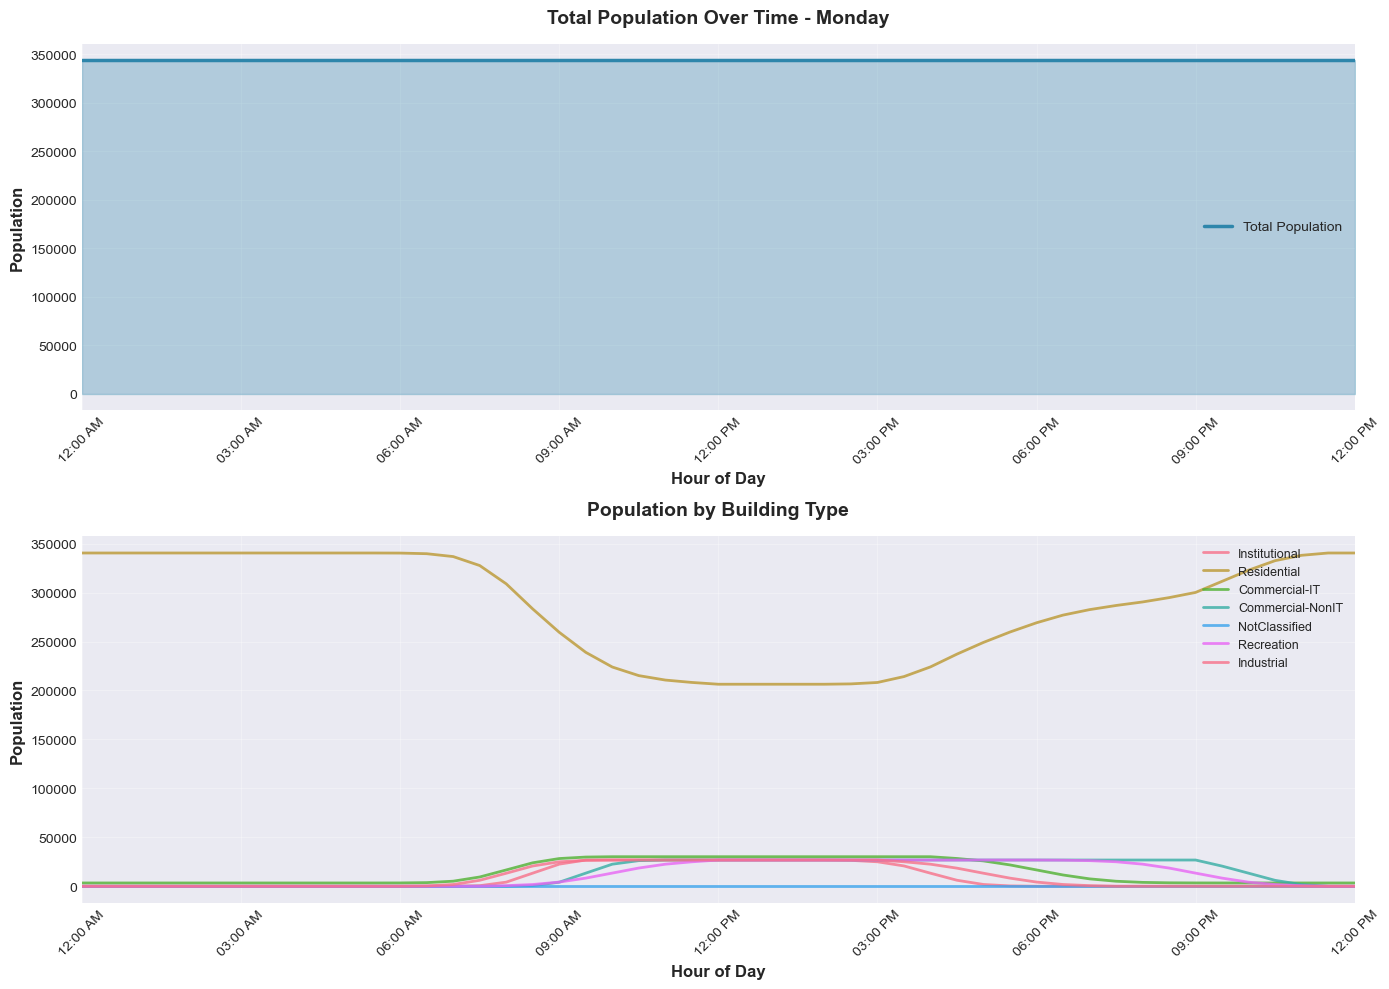

In [ ]:
if 'simulation' in locals():
    # Calculate time series statistics
    total_pop = simulation.population_matrix.sum(axis=1)

    # Create time series DataFrame
    ts_data = pd.DataFrame({
        'time': simulation.timesteps,
        'time_str': [format_time(t) for t in simulation.timesteps],
        'total_population': total_pop
    })

    # Population by building type
    for bldg_type in simulation.buildings['building_type'].unique():
        if pd.isna(bldg_type):
            continue

        bldg_indices = simulation.buildings[
            simulation.buildings['building_type'] == bldg_type
        ].index

        ts_data[bldg_type] = simulation.population_matrix[:, bldg_indices].sum(axis=1)

    # Display summary
    print("\n" + "="*80)
    print("POPULATION TIME SERIES SUMMARY")
    print("="*80)
    print(f"\nPeak population: {ts_data['total_population'].max():,}")
    peak_time = ts_data.loc[ts_data['total_population'].idxmax(), 'time_str']
    print(f"Peak time: {peak_time}")
    print(f"\nMinimum population: {ts_data['total_population'].min():,}")
    min_time = ts_data.loc[ts_data['total_population'].idxmin(), 'time_str']
    print(f"Minimum time: {min_time}")

    # Plot time series
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Total population
    ax1.plot(ts_data['time'], ts_data['total_population'],
             linewidth=2.5, color='#2E86AB', label='Total Population')
    ax1.fill_between(ts_data['time'], ts_data['total_population'],
                      alpha=0.3, color='#2E86AB')
    ax1.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Population', fontsize=12, fontweight='bold')
    ax1.set_title(f'Total Population Over Time - {simulation.day_of_week}',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 24)
    ax1.legend(fontsize=10)

    # Format x-axis with readable times
    ax1.set_xticks(range(0, 25, 3))
    ax1.set_xticklabels([format_time(h) for h in range(0, 25, 3)], rotation=45)

    # Population by building type
    building_types = [col for col in ts_data.columns
                     if col not in ['time', 'time_str', 'total_population']]

    for bldg_type in building_types:
        ax2.plot(ts_data['time'], ts_data[bldg_type],
                linewidth=2, label=bldg_type, alpha=0.8)

    ax2.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Population', fontsize=12, fontweight='bold')
    ax2.set_title('Population by Building Type',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 24)
    ax2.legend(fontsize=9, loc='upper right')
    ax2.set_xticks(range(0, 25, 3))
    ax2.set_xticklabels([format_time(h) for h in range(0, 25, 3)], rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("⚠ No simulation data available")

### 5.2 Spatial Distribution Maps

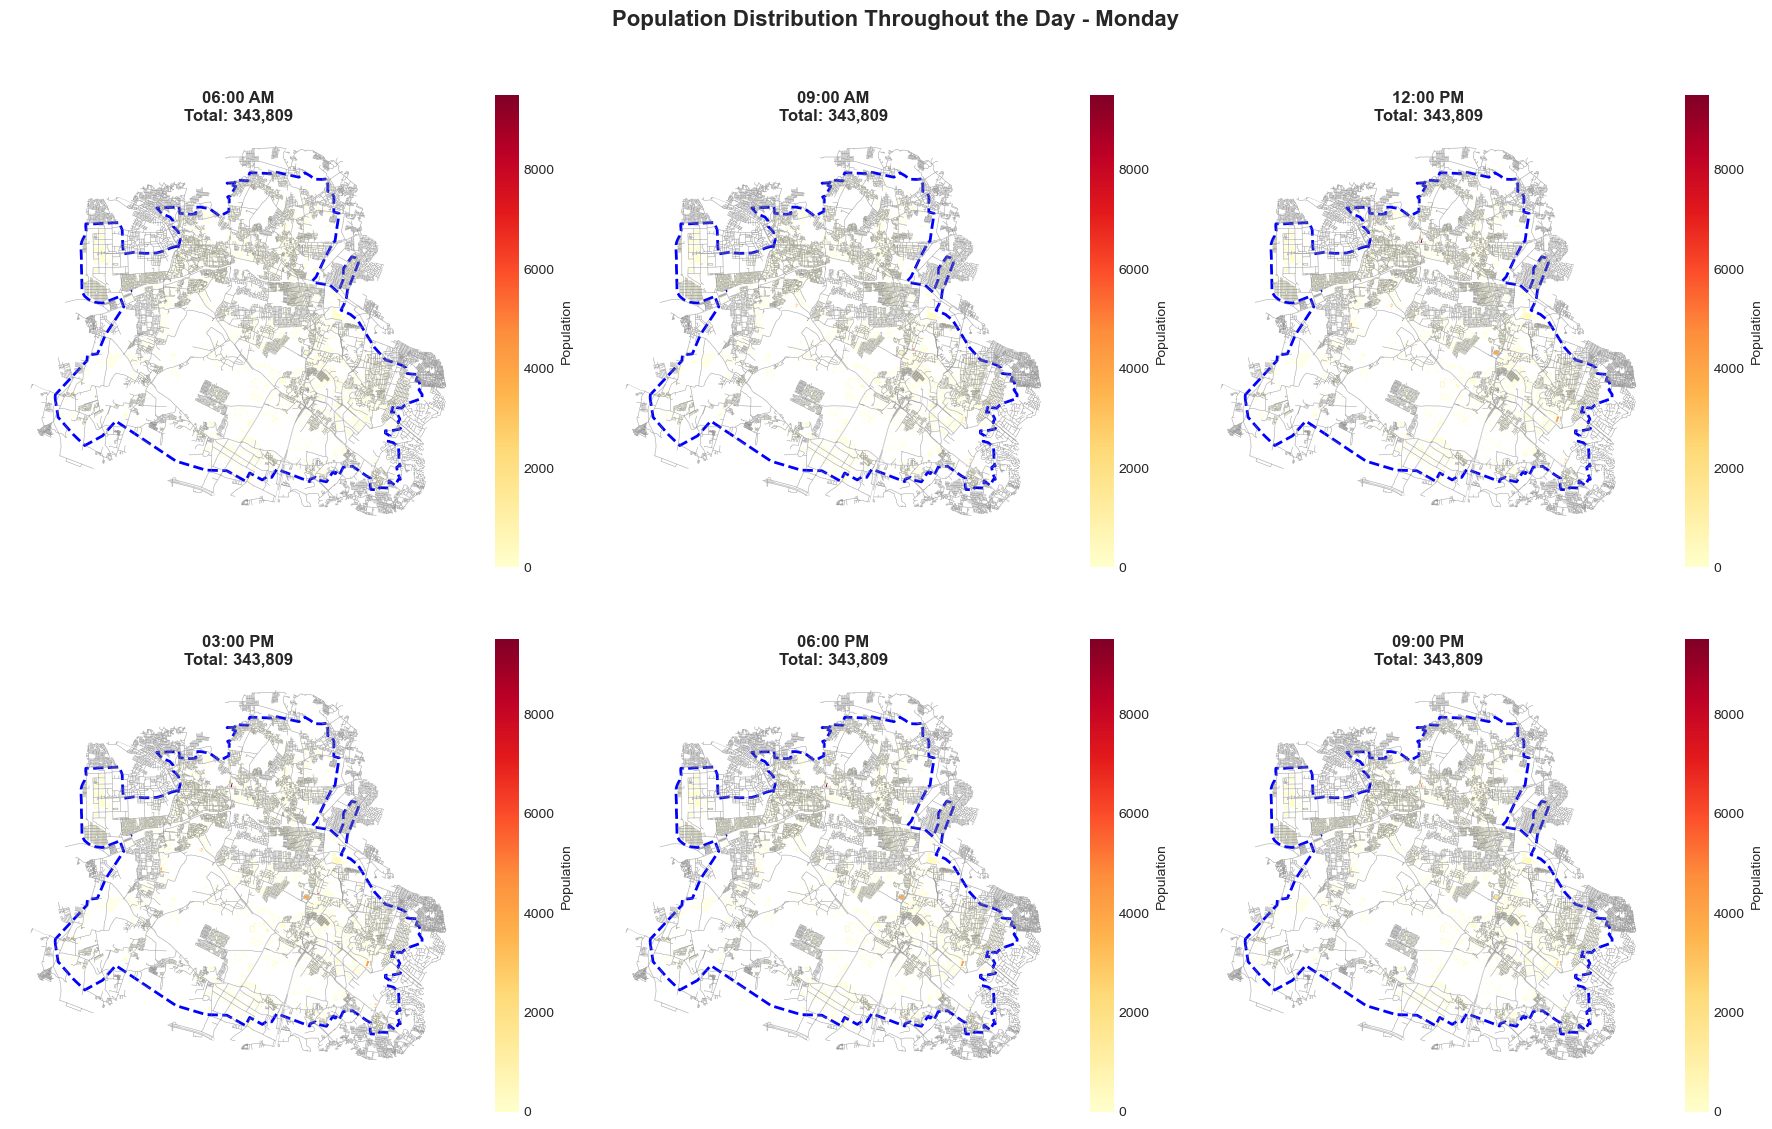

In [ ]:
if 'simulation' in locals():
    # Select key hours to visualize
    key_hours = [6, 9, 12, 15, 18, 21]  # 6 AM, 9 AM, noon, 3 PM, 6 PM, 9 PM

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Prepare data for visualization
    vis_data = simulation.buildings.copy()

    # Global min/max for consistent coloring
    vmin = 0
    vmax = simulation.population_matrix.max()

    for i, hour in enumerate(key_hours):
        ax = axes[i]

        # Get population at this hour
        time_idx = int(hour / simulation.time_interval)
        vis_data['population'] = simulation.population_matrix[time_idx, :]

        # Plot
        vis_data.plot(
            column='population',
            cmap='YlOrRd',
            legend=True,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            edgecolor='none',
            linewidth=0.1,
            legend_kwds={'label': 'Population', 'shrink': 0.8}
        )

        # Add boundary if available
        if boundary_gdf is not None:
            boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='blue',
                             linewidth=2, linestyle='--')

        # Add road network if available
        if road_network_gdf is not None:
            road_network_gdf.plot(ax=ax, color='gray', linewidth=0.3, alpha=0.5, zorder=1)

        time_str = format_time(hour)
        total_pop = vis_data['population'].sum()
        ax.set_title(f'{time_str}\nTotal: {total_pop:,.0f}',
                    fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'Population Distribution Throughout the Day - {simulation.day_of_week}',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

else:
    print("⚠ No simulation data available")

### 5.3 **NEW: Animated MP4 Visualization**

In [ ]:
if 'simulation' in locals():
    print("="*80)
    print("CREATING ANIMATED VISUALIZATIONS")
    print("="*80)

    # Check for satellite basemap support
    try:
        import contextily as ctx
        basemap_available = True
        print("✓ Satellite basemap support available")
    except ImportError:
        basemap_available = False
        print("⚠ contextily not installed - install with: pip install contextily")
        print("  Continuing without satellite basemap...")

    # Prepare visualization data
    vis_buildings = simulation.buildings.copy()

    # ========================================================================
    # CALCULATE MAP EXTENT FOR PROPER ZOOM
    # ========================================================================
    print("\n" + "="*80)
    print("CALCULATING MAP EXTENT")
    print("="*80)

    # Get bounds from buildings
    bounds = vis_buildings.total_bounds  # [minx, miny, maxx, maxy]
    minx, miny, maxx, maxy = bounds

    # Add 10% buffer for better visualization
    buffer_pct = 0.10
    x_buffer = (maxx - minx) * buffer_pct
    y_buffer = (maxy - miny) * buffer_pct

    extent = [
        minx - x_buffer,
        maxx + x_buffer,
        miny - y_buffer,
        maxy + y_buffer
    ]

    print(f"Building bounds: {bounds}")
    print(f"Map extent (with buffer): {extent}")
    print(f"CRS: {vis_buildings.crs}")

    # ========================================================================
    # PREPARE BASEMAP (if available)
    # ========================================================================
    basemap_ready = False
    if basemap_available:
        print("\n" + "="*80)
        print("PREPARING SATELLITE BASEMAP")
        print("="*80)

        try:
            # For contextily, we need to ensure CRS is Web Mercator or convert bounds
            if vis_buildings.crs.to_epsg() != 3857:
                print(f"Converting extent from {vis_buildings.crs} to Web Mercator (EPSG:3857)...")
                # Create a GeoDataFrame with the extent for transformation
                from shapely.geometry import box
                extent_gdf = gpd.GeoDataFrame(
                    geometry=[box(extent[0], extent[2], extent[1], extent[3])],
                    crs=vis_buildings.crs
                )
                extent_gdf_3857 = extent_gdf.to_crs('EPSG:3857')
                extent_3857_bounds = extent_gdf_3857.total_bounds
                print(f"Web Mercator extent: {extent_3857_bounds}")

            basemap_ready = True
            print("✓ Basemap configuration ready")

        except Exception as e:
            print(f"⚠ Could not prepare basemap: {e}")
            basemap_ready = False

    # ========================================================================
    # PREPARE COLOR SCALE
    # ========================================================================
    # Get global bounds for consistent visualization
    vmin = 0
    vmax = simulation.population_matrix.max()

    # Prepare color map with LOG SCALE for better visualization
    cmap = plt.cm.plasma
    # Use log normalization for better color distribution
    from matplotlib.colors import LogNorm
    # Add small offset to avoid log(0)
    norm = LogNorm(vmin=max(1, vmin), vmax=vmax)

    print(f"\n✓ Using logarithmic color scale for better visualization")
    print(f"  Value range: {vmin} to {vmax}")

    # Prepare time series data for chart
    total_pop_series = simulation.population_matrix.sum(axis=1)

    # Prepare road network if available
    roads_to_plot = None
    if road_network_gdf is not None:
        print("✓ Road network will be displayed")
        try:
            roads_to_plot = road_network_gdf.copy().to_crs(simulation.buildings.crs)
            # Filter to major roads for better performance
            if 'highway' in roads_to_plot.columns:
                major_road_types = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary']
                # Create mask for filtering - handle both string and list values
                def is_major_road(highway_val):
                    if pd.isna(highway_val):
                        return False
                    # Convert to string and check
                    highway_str = str(highway_val).lower()
                    return any(rt in highway_str for rt in major_road_types)

                mask = roads_to_plot['highway'].apply(is_major_road)
                roads_to_plot = roads_to_plot[mask].copy()
                print(f"  Major roads filtered: {len(roads_to_plot):,} segments")
        except Exception as e:
            print(f"  ⚠ Could not filter roads: {e}")
            print(f"  Using all roads")

    # ========================================================================
    # ANIMATION 1: MAP ONLY
    # ========================================================================
    print("\n" + "="*80)
    print("CREATING MAP ANIMATION")
    print("="*80)

    # Create figure with BLACK background
    fig_map, ax_map = plt.subplots(1, 1, figsize=(12, 10), facecolor='black')
    ax_map.set_facecolor('black')

    # Create a single colorbar that won't be recreated
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_map, fraction=0.03, pad=0.04)
    cbar.set_label('Population per Building (log scale)', fontsize=11, fontweight='bold', color='white')
    # Make colorbar text white
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
    # Make colorbar spine white
    cbar.outline.set_edgecolor('white')

    def animate_map(frame):
        """Animation function for map only."""
        ax_map.clear()
        ax_map.set_facecolor('black')  # Reset background to black each frame

        # Current time
        current_time = simulation.timesteps[frame]
        time_str = format_time(current_time)

        # Add small offset to avoid log(0) issues
        vis_buildings['population'] = simulation.population_matrix[frame, :] + 1

        # Plot buildings FIRST to establish the coordinate system
        vis_buildings.plot(
            column='population',
            cmap=cmap,
            ax=ax_map,
            norm=norm,
            edgecolor='none',
            linewidth=0.3,
            alpha=0.85,
            zorder=3
        )

        # Set extent BEFORE adding basemap
        ax_map.set_xlim(extent[0], extent[1])
        ax_map.set_ylim(extent[2], extent[3])

        # Add satellite basemap (AFTER buildings establish coordinate system)
        if basemap_ready:
            try:
                ctx.add_basemap(
                    ax=ax_map,
                    crs=vis_buildings.crs.to_string(),
                    source=ctx.providers.Esri.WorldImagery,
                    alpha=0.6,
                    zorder=0,
                    attribution=False
                )
            except Exception as e:
                if frame == 0:
                    print(f"⚠ Could not load basemap: {e}")

        # Add road network (middle layer)
        if roads_to_plot is not None:
            roads_to_plot.plot(
                ax=ax_map,
                color='white',
                linewidth=1.2,
                alpha=0.7,
                zorder=2
            )

        # Re-plot buildings on top
        vis_buildings.plot(
            column='population',
            cmap=cmap,
            ax=ax_map,
            norm=norm,
            edgecolor='none',
            linewidth=0.3,
            alpha=0.85,
            zorder=3
        )

        # Add boundary if available
        if boundary_gdf is not None:
            boundary_gdf.plot(
                ax=ax_map,
                facecolor='none',
                edgecolor='cyan',
                linewidth=3,
                linestyle='--',
                alpha=0.9,
                zorder=4
            )

        # Ensure extent is maintained
        ax_map.set_xlim(extent[0], extent[1])
        ax_map.set_ylim(extent[2], extent[3])

        # Map title and styling (subtract the offset for display)
        current_pop = (vis_buildings['population'] - 1).sum()
        ax_map.set_title(
            f'Gachibowli Population - {simulation.day_of_week}\nTime: {time_str} | Total: {current_pop:,.0f}',
            fontsize=15,
            fontweight='bold',
            pad=20,
            color='white'  # WHITE TEXT
        )
        ax_map.axis('off')

        return ax_map,

    # Timing: 30 minutes = 0.5 seconds, so 1 hour = 1 second
    # With 49 frames (0.5h intervals), we want 24 seconds total
    # FPS = frames / seconds = 49 / 24 ≈ 2.04 FPS
    # interval = 1000ms / 2.04 ≈ 490ms per frame
    fps_map = len(simulation.timesteps) / 24.0
    interval_map = 1000.0 / fps_map

    print("\nGenerating map animation...")
    print(f"Total frames: {len(simulation.timesteps)}")
    print(f"Animation timing: 30 min = 0.5 sec (1 hour = 1 sec)")
    print(f"Video duration: 24 seconds for full day")
    print(f"FPS: {fps_map:.2f}, Interval: {interval_map:.1f}ms")

    anim_map = animation.FuncAnimation(
        fig_map,
        animate_map,
        frames=len(simulation.timesteps),
        interval=interval_map,
        blit=False,
        repeat=True
    )

    # Save map animation
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    map_output_path = os.path.join(OUTPUT_DIR, f'population_map_{timestamp}.mp4')

    print(f"\nSaving map animation to: {map_output_path}")
    print("This may take a few minutes...")

    writer_map = animation.FFMpegWriter(
        fps=fps_map,
        bitrate=3000,
        metadata={
            'title': 'Gachibowli Population Map',
            'artist': 'DiurnalSimulation',
            'comment': f'Map animation for {simulation.day_of_week} - 30min=0.5sec timing'
        }
    )

    anim_map.save(map_output_path, writer=writer_map, dpi=150)
    plt.close(fig_map)

    map_file_size_mb = os.path.getsize(map_output_path) / (1024 * 1024)
    print(f"✓ Map animation saved: {map_file_size_mb:.2f} MB")

    # ========================================================================
    # ANIMATION 2: TIME SERIES CHART ONLY
    # ========================================================================
    print("\n" + "="*80)
    print("CREATING TIME SERIES ANIMATION")
    print("="*80)

    # Create figure with BLACK background
    fig_chart, ax_chart = plt.subplots(1, 1, figsize=(14, 8), facecolor='black')
    ax_chart.set_facecolor('black')

    def animate_chart(frame):
        """Animation function for time series chart only."""
        ax_chart.clear()
        ax_chart.set_facecolor('black')  # Reset background to black

        # Current time
        current_time = simulation.timesteps[frame]
        time_str = format_time(current_time)

        # Plot full time series
        ax_chart.plot(
            simulation.timesteps,
            total_pop_series,
            linewidth=2.5,
            color='cyan',  # Cyan for better visibility on black
            alpha=0.8,
            label='Total Population'
        )

        # Highlight current position
        ax_chart.axvline(
            current_time,
            color='red',
            linewidth=3,
            linestyle='--',
            alpha=0.8,
            label=f'Current Time: {time_str}'
        )

        # Highlight past
        ax_chart.fill_between(
            simulation.timesteps[:frame+1],
            total_pop_series[:frame+1],
            alpha=0.3,
            color='cyan'
        )

        # Add current population marker
        current_pop = total_pop_series[frame]
        ax_chart.scatter(
            current_time,
            current_pop,
            s=200,
            color='red',
            zorder=5,
            edgecolor='white',
            linewidth=3
        )

        # Add annotation for current value
        ax_chart.annotate(
            f'{current_pop:,.0f}',
            xy=(current_time, current_pop),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=11,
            fontweight='bold',
            color='black',  # Black text on yellow background
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.9),
            zorder=6
        )

        # Chart formatting with WHITE text
        ax_chart.set_xlabel('Hour of Day', fontsize=13, fontweight='bold', color='white')
        ax_chart.set_ylabel('Total Population', fontsize=13, fontweight='bold', color='white')
        ax_chart.set_title(
            f'Population Time Series - {simulation.day_of_week}',
            fontsize=16,
            fontweight='bold',
            pad=20,
            color='white'
        )
        ax_chart.grid(True, alpha=0.2, linestyle=':', linewidth=1.5, color='white')
        ax_chart.set_xlim(0, 24)
        ax_chart.set_ylim(
            total_pop_series.min() * 0.95,
            total_pop_series.max() * 1.05
        )

        # X-axis and Y-axis labels in WHITE
        ax_chart.set_xticks(range(0, 25, 3))
        ax_chart.set_xticklabels(
            [format_time(h) for h in range(0, 25, 3)],
            rotation=45,
            ha='right',
            fontsize=10,
            color='white'
        )
        ax_chart.tick_params(axis='x', colors='white')
        ax_chart.tick_params(axis='y', colors='white')

        # Make spines white
        for spine in ax_chart.spines.values():
            spine.set_edgecolor('white')

        # Legend with white text
        legend = ax_chart.legend(loc='upper right', fontsize=11, framealpha=0.8)
        legend.get_frame().set_facecolor('black')
        legend.get_frame().set_edgecolor('white')
        for text in legend.get_texts():
            text.set_color('white')

        return ax_chart,

    # Create chart animation with same timing as map
    print(f"Using same timing: 30 min = 0.5 sec, 24 sec total")

    anim_chart = animation.FuncAnimation(
        fig_chart,
        animate_chart,
        frames=len(simulation.timesteps),
        interval=interval_map,
        blit=False,
        repeat=True
    )

    # Save chart animation
    chart_output_path = os.path.join(OUTPUT_DIR, f'population_timeseries_{timestamp}.mp4')

    print(f"\nSaving time series animation to: {chart_output_path}")

    writer_chart = animation.FFMpegWriter(
        fps=fps_map,
        bitrate=2000,
        metadata={
            'title': 'Gachibowli Population Time Series',
            'artist': 'DiurnalSimulation',
            'comment': f'Time series for {simulation.day_of_week} - 30min=0.5sec timing'
        }
    )

    anim_chart.save(chart_output_path, writer=writer_chart, dpi=120)
    plt.close(fig_chart)

    chart_file_size_mb = os.path.getsize(chart_output_path) / (1024 * 1024)
    print(f"✓ Time series animation saved: {chart_file_size_mb:.2f} MB")

    # ========================================================================
    # STATIC SNAPSHOTS AT KEY HOURS
    # ========================================================================
    print("\n" + "="*80)
    print("CREATING STATIC SNAPSHOTS")
    print("="*80)

    key_hours = [6, 9, 12, 15, 18, 21]

    for hour in key_hours:
        time_idx = int(hour / simulation.time_interval)
        current_time = simulation.timesteps[time_idx]
        time_str = format_time(current_time)

        # Create figure with BLACK background
        fig_snap, ax_snap = plt.subplots(1, 1, figsize=(12, 10), facecolor='black')
        ax_snap.set_facecolor('black')

        # Add offset for log scale
        vis_buildings['population'] = simulation.population_matrix[time_idx, :] + 1

        # Plot buildings first to establish coordinate system
        vis_buildings.plot(
            column='population',
            cmap=cmap,
            ax=ax_snap,
            norm=norm,
            edgecolor='none',
            linewidth=0.3,
            alpha=0.85,
            legend=True,
            legend_kwds={'label': 'Population (log scale)', 'shrink': 0.8},
            zorder=3
        )

        # Set extent
        ax_snap.set_xlim(extent[0], extent[1])
        ax_snap.set_ylim(extent[2], extent[3])

        # Add satellite basemap
        if basemap_ready:
            try:
                ctx.add_basemap(
                    ax=ax_snap,
                    crs=vis_buildings.crs.to_string(),
                    source=ctx.providers.Esri.WorldImagery,
                    alpha=0.6,
                    zorder=0,
                    attribution=False
                )
            except Exception as e:
                if hour == key_hours[0]:
                    print(f"⚠ Could not load basemap for snapshots: {e}")

        # Add roads
        if roads_to_plot is not None:
            roads_to_plot.plot(ax=ax_snap, color='grey', linewidth=0.3, alpha=0.5, zorder=2)

        # Re-plot buildings on top
        vis_buildings.plot(
            column='population',
            cmap=cmap,
            ax=ax_snap,
            norm=norm,
            edgecolor='none',
            linewidth=0.3,
            alpha=0.85,
            legend=True,
            legend_kwds={'label': 'Population (log scale)', 'shrink': 0.8},
            zorder=3
        )

        # Add boundary
        if boundary_gdf is not None:
            boundary_gdf.plot(ax=ax_snap, facecolor='none', edgecolor='cyan',
                            linewidth=3, linestyle='--', alpha=0.9, zorder=4)

        # Ensure extent
        ax_snap.set_xlim(extent[0], extent[1])
        ax_snap.set_ylim(extent[2], extent[3])

        current_pop = (vis_buildings['population'] - 1).sum()
        ax_snap.set_title(
            f'Gachibowli Population - {simulation.day_of_week}\nTime: {time_str} | Total: {current_pop:,.0f}',
            fontsize=15,
            fontweight='bold',
            pad=20,
            color='white'  # WHITE TEXT
        )
        ax_snap.axis('off')

        # Save snapshot with black background
        snapshot_path = os.path.join(OUTPUT_DIR, f'snapshot_{hour:02d}h_{timestamp}.png')
        plt.savefig(snapshot_path, dpi=150, bbox_inches='tight', facecolor='black')
        plt.close(fig_snap)

        print(f"✓ Saved snapshot: {time_str}")

    # ========================================================================
    # SUMMARY
    # ========================================================================
    print("\n" + "="*80)
    print("VISUALIZATION COMPLETE!")
    print("="*80)
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"\nFiles created:")
    print(f"  1. Map animation: population_map_{timestamp}.mp4 ({map_file_size_mb:.2f} MB)")
    print(f"  2. Time series: population_timeseries_{timestamp}.mp4 ({chart_file_size_mb:.2f} MB)")
    print(f"  3. Snapshots: {len(key_hours)} PNG images at key hours")
    print(f"\nDuration: 24 seconds @ {fps_map:.2f} FPS (30 min = 0.5 sec)")
    print(f"\n✓ Color scale: Logarithmic (better for wide value ranges)")
    print(f"✓ Map extent: Properly set with 10% buffer around buildings")
    print(f"✓ Background: Black with white text for better contrast")
    print(f"✓ Timing: 1 hour simulation = 1 second video")
    print(f"✓ Basemap: {'Enabled (Esri WorldImagery)' if basemap_ready else 'Disabled'}")

else:
    print("⚠ No simulation data available")

CREATING ANIMATED VISUALIZATIONS
✓ Satellite basemap support available

CALCULATING MAP EXTENT
Building bounds: [ 210270.39422866 1926774.5777503   224545.68549876 1939278.01822132]
Map extent (with buffer): [208842.86510165271, 225973.21462576443, 1925524.2337032005, 1940528.3622684225]
CRS: EPSG:32644

PREPARING SATELLITE BASEMAP
Converting extent from EPSG:32644 to Web Mercator (EPSG:3857)...
Web Mercator extent: [8711604.60832188 1967053.14033371 8729764.35560691 1983115.03948816]
✓ Basemap configuration ready

✓ Using logarithmic color scale for better visualization
  Value range: 0 to 9496.0
✓ Road network will be displayed
  ⚠ Could not filter roads: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
  Using all roads

CREATING MAP ANIMATION

Generating map animation...
Total frames: 49
Animation timing: 30 min = 0.5 sec (1 hour = 1 sec)
Video duration: 24 seconds for full day
FPS: 2.04, Interval: 489.8ms

Saving map animation to: /Users/

---
## 6. Visualization and Analysis

*Note: Data is already exported in Section 5, so these visualizations are independent.*

### 6.1 Save All Simulation Outputs

In [ ]:
def save_simulation_outputs(simulation, output_dir=OUTPUT_DIR):
    """
    Save simulation results in multiple formats.

    Outputs:
    --------
    1. Time series CSV
    2. Summary statistics CSV
    3. Buildings shapefile with population snapshots
    4. Raw population matrix (NumPy)
    5. Metadata JSON
    """
    print("\n" + "="*80)
    print("SAVING SIMULATION OUTPUTS")
    print("="*80)

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # === 1. TIME SERIES CSV ===
    print("\n1. Saving time series data...")

    ts_data = pd.DataFrame({
        'timestep': range(simulation.n_timesteps),
        'time_hours': simulation.timesteps,
        'time_str': [format_time(t) for t in simulation.timesteps],
        'total_population': simulation.population_matrix.sum(axis=1)
    })

    # Add population by building type
    for bldg_type in simulation.buildings['building_type'].unique():
        if pd.isna(bldg_type):
            continue
        bldg_indices = simulation.buildings[
            simulation.buildings['building_type'] == bldg_type
        ].index
        ts_data[f'pop_{bldg_type}'] = simulation.population_matrix[:, bldg_indices].sum(axis=1)

    ts_path = os.path.join(output_dir, f'timeseries_{timestamp}.csv')
    ts_data.to_csv(ts_path, index=False)
    print(f"   ✓ Saved: {ts_path}")
    print(f"   Records: {len(ts_data):,}")

    # === 2. SUMMARY STATISTICS CSV ===
    print("\n2. Saving summary statistics...")

    summary_path = os.path.join(output_dir, f'summary_{timestamp}.csv')
    ts_data.to_csv(summary_path, index=False)
    print(f"   ✓ Saved: {summary_path}")

    # === 3. BUILDINGS SHAPEFILE ===
    print("\n3. Saving buildings shapefile...")

    buildings_export = simulation.buildings.copy()

    # Add population snapshots for key hours
    key_hours = [0, 6, 9, 12, 15, 18, 21, 23]
    for hour in key_hours:
        time_idx = int(hour / simulation.time_interval)
        buildings_export[f'pop_{hour:02d}h'] = simulation.population_matrix[time_idx, :]

    # Simplify column names for shapefile (10-char limit)
    export_cols = ['geometry', 'LU_B_PRJ'] + [f'pop_{h:02d}h' for h in key_hours]
    buildings_export = buildings_export[export_cols]

    shp_path = os.path.join(output_dir, f'buildings_{timestamp}.shp')
    buildings_export.to_file(shp_path)
    print(f"   ✓ Saved: {shp_path}")
    print(f"   Buildings: {len(buildings_export):,}")
    print(f"   Snapshots: {key_hours}")

    # === 4. RAW MATRIX (NumPy) ===
    print("\n4. Saving raw population matrix...")

    matrix_path = os.path.join(output_dir, f'matrix_{timestamp}.npy')
    np.save(matrix_path, simulation.population_matrix)
    print(f"   ✓ Saved: {matrix_path}")
    print(f"   Shape: {simulation.population_matrix.shape}")

    # === 5. METADATA (JSON) ===
    print("\n5. Saving metadata...")

    metadata = {
        'timestamp': timestamp,
        'day_of_week': simulation.day_of_week,
        'n_buildings': simulation.n_buildings,
        'n_timesteps': simulation.n_timesteps,
        'time_interval_hours': simulation.time_interval,
        'total_individuals': simulation.n_individuals,
        'total_population': int(simulation.population_matrix[0, :].sum()),
        'building_types': simulation.buildings['building_type'].value_counts().to_dict(),
        'employment_distribution': EMPLOYMENT_DISTRIBUTION,
        'key_hours': key_hours
    }

    metadata_path = os.path.join(output_dir, f'metadata_{timestamp}.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"   ✓ Saved: {metadata_path}")

    # Summary
    print("\n" + "="*80)
    print("EXPORT COMPLETE!")
    print("="*80)
    print(f"\nAll files saved to: {output_dir}")

    return {
        'output_dir': output_dir,
        'timestamp': timestamp,
        'files': {
            'timeseries': os.path.basename(ts_path),
            'summary': os.path.basename(summary_path),
            'buildings': os.path.basename(shp_path),
            'matrix': os.path.basename(matrix_path),
            'metadata': os.path.basename(metadata_path)
        }
    }


# Execute save
if 'simulation' in locals():
    save_info = save_simulation_outputs(simulation)
else:
    print("⚠ No simulation data to save")


SAVING SIMULATION OUTPUTS

1. Saving time series data...
   ✓ Saved: /Users/va/Geospatial/outputs/timeseries_20251118_133539.csv
   Records: 49

2. Saving summary statistics...
   ✓ Saved: /Users/va/Geospatial/outputs/summary_20251118_133539.csv

3. Saving buildings shapefile...
   ✓ Saved: /Users/va/Geospatial/outputs/buildings_20251118_133539.shp
   Buildings: 53,797
   Snapshots: [0, 6, 9, 12, 15, 18, 21, 23]

4. Saving raw population matrix...
   ✓ Saved: /Users/va/Geospatial/outputs/matrix_20251118_133539.npy
   Shape: (49, 53797)

5. Saving metadata...
   ✓ Saved: /Users/va/Geospatial/outputs/metadata_20251118_133539.json

EXPORT COMPLETE!

All files saved to: /Users/va/Geospatial/outputs


---
## 7. Summary and Next Steps

In [ ]:
if 'simulation' in locals():
    print("\n" + "="*80)
    print("SIMULATION SUMMARY")
    print("="*80)

    print(f"\nDay Simulated: {simulation.day_of_week}")
    print(f"Total Buildings: {simulation.n_buildings:,}")
    print(f"Total Individuals: {simulation.n_individuals:,}")
    print(f"Time Steps: {simulation.n_timesteps} ({int(simulation.time_interval*60)}-minute intervals)")

    # Peak statistics
    total_pop = simulation.population_matrix.sum(axis=1)
    peak_idx = np.argmax(total_pop)
    peak_time = simulation.timesteps[peak_idx]
    peak_pop = total_pop[peak_idx]

    print(f"\nPeak Population: {peak_pop:,.0f}")
    print(f"Peak Time: {format_time(peak_time)}")

    # Files created
    if 'save_info' in locals():
        print(f"\nOutput Directory: {save_info['output_dir']}")
        print("\nFiles Created:")
        for file_type, filename in save_info['files'].items():
            print(f"  • {file_type}: {filename}")

    print("\n" + "="*80)
    print("NEXT STEPS")
    print("="*80)
    print("""
1. Review the MP4 animation to visualize population movement
2. Analyze time series data for peak hours and patterns
3. Examine building-level population distributions
4. Use exported shapefiles in GIS software for further analysis
5. Experiment with different days (weekday vs weekend)
6. Adjust employment distributions or work schedules
    """)

else:
    print("⚠ Please run the simulation first")


SIMULATION SUMMARY

Day Simulated: Monday
Total Buildings: 53,797
Total Individuals: 340,434
Time Steps: 49 (30-minute intervals)

Peak Population: 343,809
Peak Time: 12:00 AM

Output Directory: /Users/va/Geospatial/outputs

Files Created:
  • timeseries: timeseries_20251118_133539.csv
  • summary: summary_20251118_133539.csv
  • buildings: buildings_20251118_133539.shp
  • matrix: matrix_20251118_133539.npy
  • metadata: metadata_20251118_133539.json

NEXT STEPS

1. Review the MP4 animation to visualize population movement
2. Analyze time series data for peak hours and patterns
3. Examine building-level population distributions
4. Use exported shapefiles in GIS software for further analysis
5. Experiment with different days (weekday vs weekend)
6. Adjust employment distributions or work schedules
    
